#IMPORTACIONES


In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import hashlib
import requests
import io

#CARGA DEL DATASET

In [161]:
url = "https://raw.githubusercontent.com/Mapabaoy12/EncargoMachineLearning1/refs/heads/main/dataset/Spotify_Tracks_Dataset.csv"
HASH_ORIGINAL = "b202fa49909b2d5cef71a04b1d21243cfeb36414535f2ca9272aa646721177bd"


In [162]:
try:
    # intento de descarga y validación
    response = requests.get(url)
    response.raise_for_status()  # verifica que url funcione y no de error

    contenido_raw = response.content
    hash_calculado = hashlib.sha256(contenido_raw).hexdigest()

    if hash_calculado == HASH_ORIGINAL:
        print("AUDITORÍA EXITOSA: Integridad de procedencia garantizada.")
        df = pd.read_csv(io.BytesIO(contenido_raw))
        print("Dataset cargado correctamente.")
    else:
        # si hash no coincide, da un error manual
        raise ValueError("El hash no coincide. El archivo ha sido modificado o está corrupto.")

except Exception as e:
    # captura cualquier error y detiene el proceso
    raise RuntimeError(f"FALLO CRÍTICO: No se pudo procesar el dataset. Detalle: {e}")

AUDITORÍA EXITOSA: Integridad de procedencia garantizada.
Dataset cargado correctamente.


#VARIABLES DATASET

"track_id":Identificador de spotify para la cancion\
"artists":Artista de la cancion, si hay mas de uno se separa con ;\
"album_name":Album donde la cancion aparece\
"track_name":Nombre de la pista de audio musical\
"popularity":Popularidad de la cancion bajo una puntuacion de 0 a 100\
"duration_ms":Duracion en segundos\
"explicit":Contenido explicito de la cancion(letras) variable False o True\
"danceability":Escala que denomina que tan bailable es una cancion de 0.0 a 1.0\
"energy":Intensidad de la cancion medida en 0.0 a 1.0\
"key":\ Tonalidad / escala de notas de la canción, del 0 al 11
"loudness":Sonoridad de la cancion medida en decibeles\
"mode":Escala melodica de la cancion\
"speechiness":Cantidad de palabras en escala de 0.0 a 1.0\
"acousticness":Escala de 0.0 a 1.0 para medir si una cancion es acustica\
"instrumentalness":Escala de 0.0 a 1.0 para medir si una cancion es mas instrumental\
"liveness":Escala de 0.0 a 1.0 para medir si la cancion fue cantada en live\
"valence":Positividad medida en 0.0 a 1.0\
"tempo": Tempo estimado de la cancion\
"time_signature":Cantidad de beats en una cancion\
"track_genre":Genero de la cancion


#EDAAAAAAAAAAA

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [164]:
# Al dataframe le sacamos la columna "Unnamed: 0" por la nula relevancia predictiva
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [165]:
# Cantidad total de géneros únicos (excluyendo nulos por defecto)
total_generos = df['track_genre'].nunique()
print(f"Total de géneros únicos: {total_generos}")

Total de géneros únicos: 114


In [166]:
# Resumen estructurado de duplicados y cardinalidad por columna
resumen_duplicados = pd.DataFrame({
    'columna': df.columns,
    'tipo_dato': df.dtypes.values,
    'total_filas': len(df),
    'valores_unicos': [df[col].nunique(dropna=False) for col in df.columns],
    'duplicados_individuales': [df[col].duplicated().sum() for col in df.columns],
    'pct_duplicados': [(df[col].duplicated().sum() / len(df)) * 100 for col in df.columns]
})

print(resumen_duplicados)

             columna tipo_dato  total_filas  valores_unicos  \
0           track_id    object       114000           89741   
1            artists    object       114000           31438   
2         album_name    object       114000           46590   
3         track_name    object       114000           73609   
4         popularity     int64       114000             101   
5        duration_ms     int64       114000           50697   
6           explicit      bool       114000               2   
7       danceability   float64       114000            1174   
8             energy   float64       114000            2083   
9                key     int64       114000              12   
10          loudness   float64       114000           19480   
11              mode     int64       114000               2   
12       speechiness   float64       114000            1489   
13      acousticness   float64       114000            5061   
14  instrumentalness   float64       114000            

In [167]:

# buscar duplicado considerando track_id y track_genre
duplicados_id = df[df.duplicated(subset=['track_id', 'track_genre'], keep=False)].sort_values(by='track_id')
duplicados_id.shape

(894, 20)

aunque haya 894 duplicados que son IGUALES, se van a eliminar, pero siguen habiendo +23000 que tienen casi todas las variables iguales MENOS género, lo que conlleva a que esos 23000 duplicados restantes van a afectar el resto de variables

In [168]:
#Eliminacion de duplicados que tengan el "track_id" y "track_genre" igual
df.drop_duplicates(subset=['track_id', 'track_genre'], inplace=True)


In [169]:
variables_cuantitativas = ["popularity", "duration_ms", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "tempo", "time_signature"]
variables_cualitativas = [ "artists", "album_name", "track_name", "track_genre"]


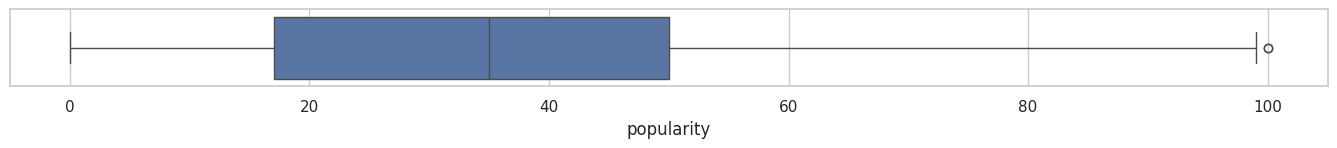

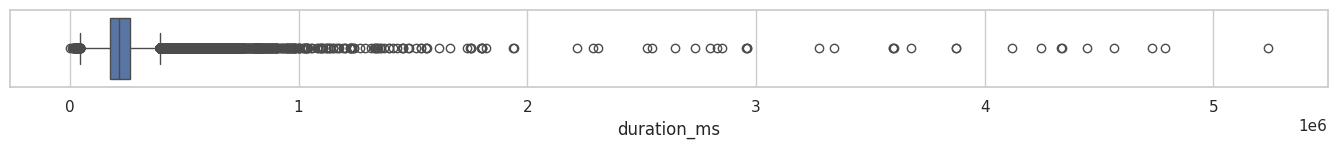

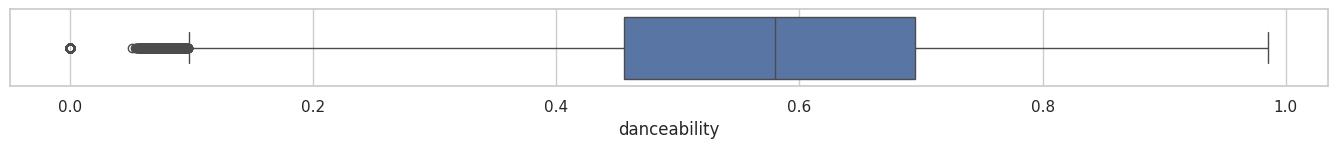

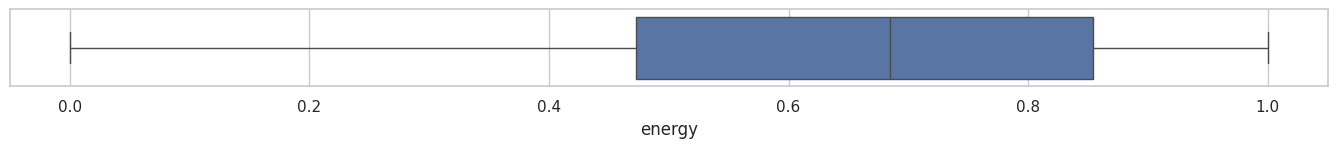

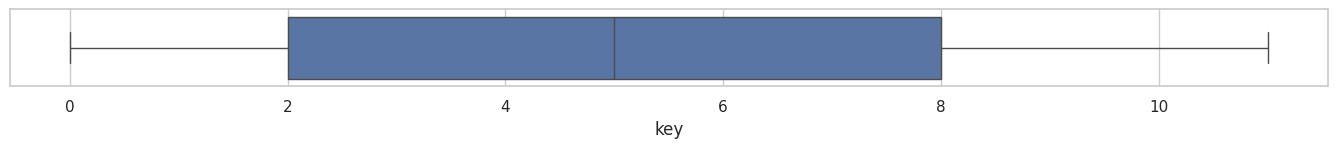

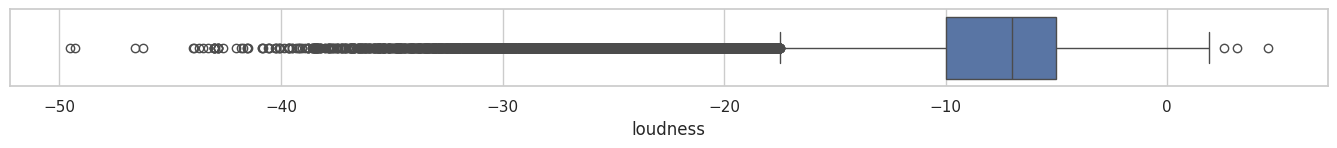

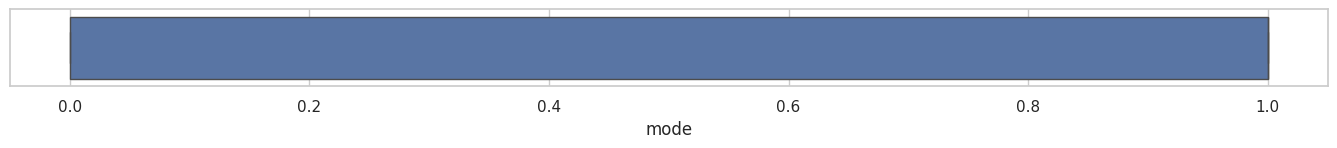

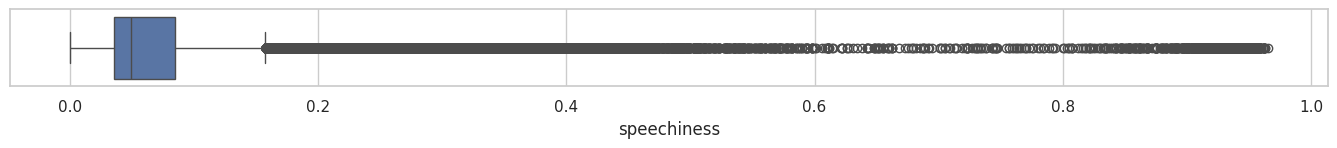

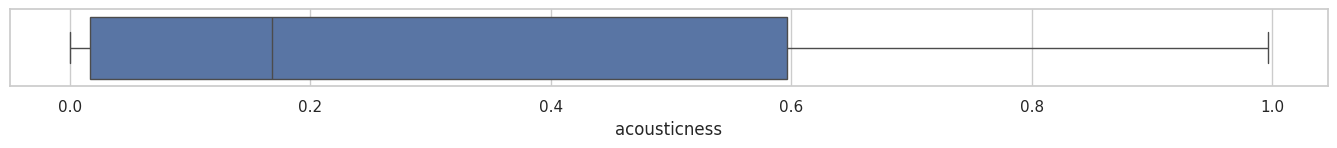

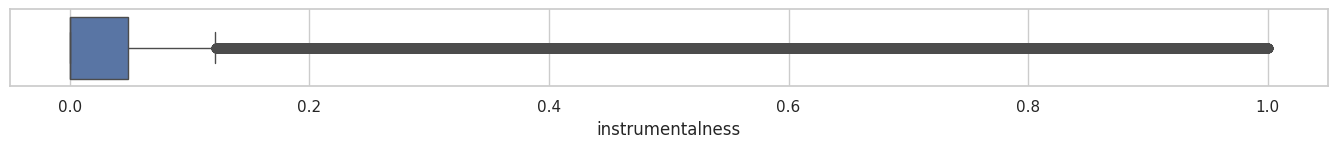

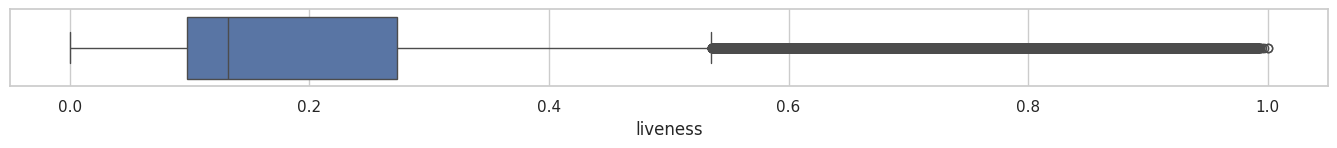

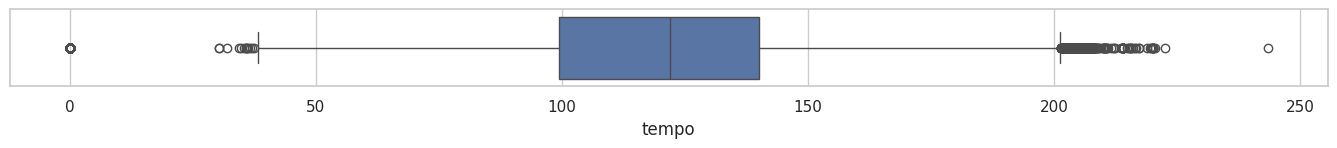

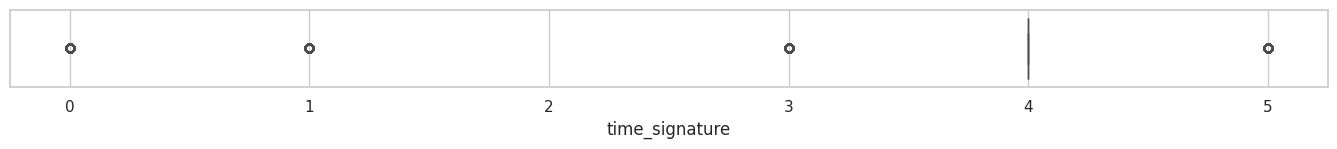

In [170]:
#Comprobación de outliers
for col in variables_cuantitativas:
    plt.figure(figsize = (17,1))
    sns.boxplot(data=df[variables_cuantitativas], x = col)
    #Este ciclo for nos permite visualisar las columnas numéricas con su visualización bajo boxplot para ver la presencia de outliers dentro de nuestros datos



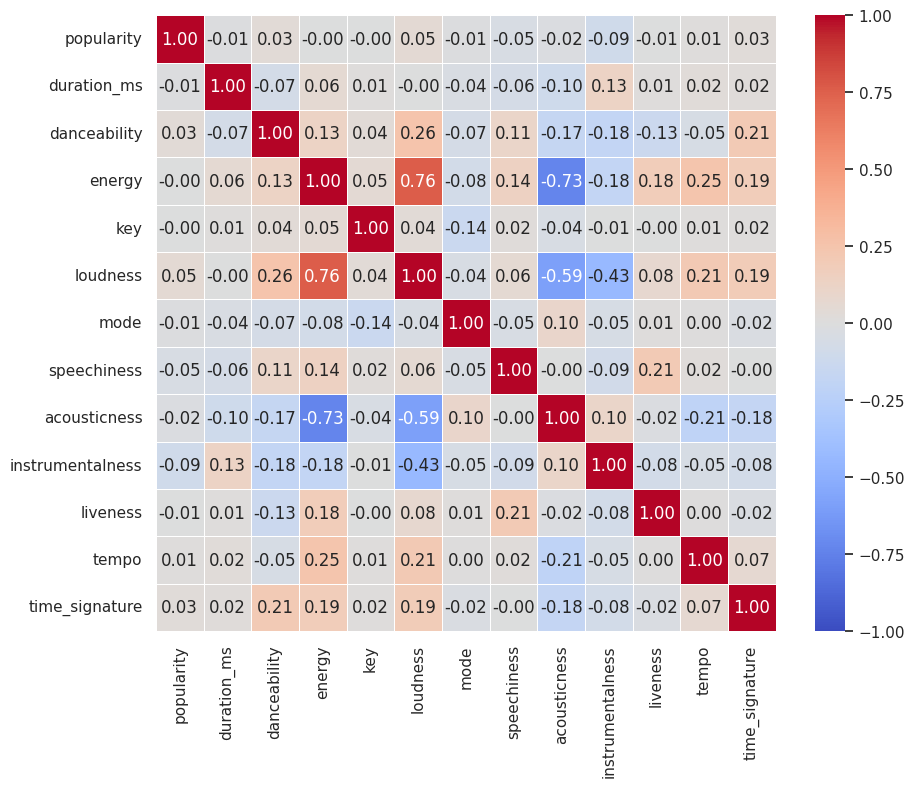

In [171]:
matriz_corr = df[variables_cuantitativas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.show()

In [172]:
#Debido a la alta correlacion entre "loudness" y "key" se compararan con la variable objetivo
var1= 'loudness'
var2= 'energy'
target= 'popularity'
corr1= abs(df[var1].corr(df[target]))
corr2= abs(df[var2].corr(df[target]))
print(f"Impacto de '{var1}': {corr1:.4f}")
print(f"Impacto de '{var2}': {corr2:.4f}")

Impacto de 'loudness': 0.0474
Impacto de 'energy': 0.0024


Como tal estas variables tienen una correlacion practicamente nula con la objetivo, que dicen chiquis elimnamos 1 o las dejamos? opino que eliminemos energy ya que es la que menos tiene entre ambas y no aportaria nada.

In [173]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# 1. Binarizar o categorizar la popularidad (ej. por umbral de negocio)
df['popularity_cat'] = pd.qcut(df['popularity'], q=5)

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))

# 2. Calcular solo sobre variables de cardinalidad manejable (como track_genre)
#v_cramer = cramers_v(df['track_genre'], df['popularity_cat'])
#print(f"V de Cramér (track_genre vs popularity_cat): {v_genre:.4f}")

for col in variables_cualitativas:
    v_cramer = cramers_v(df[col], df['popularity_cat'])
    print(f"V de Cramér ({col} vs popularity_cat): {v_cramer:.4f}")


V de Cramér (artists vs popularity_cat): 0.8381
V de Cramér (album_name vs popularity_cat): 0.9232
V de Cramér (track_name vs popularity_cat): 0.9406
V de Cramér (track_genre vs popularity_cat): 0.5432


In [174]:
df["popularity_cat"].unique()

[(54.0, 100.0], (41.0, 54.0], (-0.001, 10.0], (10.0, 26.0], (26.0, 41.0]]
Categories (5, interval[float64, right]): [(-0.001, 10.0] < (10.0, 26.0] < (26.0, 41.0] <
                                           (41.0, 54.0] < (54.0, 100.0]]

In [175]:
import numpy as np
# Recupera la versión original de los datos
data_4 = df.copy()
# Obtiene las columnas a codificar
categorical_features = data_4.describe(include = ['object']).columns
# Calcula el promedio de la variable objetivo (calidad) por cada columna
for feature in categorical_features:
  mean_encoded = data_4.groupby(feature)['popularity'].mean()

  # Asigna este promedio a la columna codificada en el DataFrame
  data_4[f'{feature}_codificado'] = data_4[feature].map(mean_encoded)

data_4.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,valence,tempo,time_signature,track_genre,popularity_cat,track_id_codificado,artists_codificado,album_name_codificado,track_name_codificado,track_genre_codificado
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.715,87.917,4,acoustic,"(54.0, 100.0]",73.0,58.000000,73.0,73.000000,42.483
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.267,77.489,4,acoustic,"(54.0, 100.0]",55.0,42.923077,55.0,50.666667,42.483
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.120,76.332,4,acoustic,"(54.0, 100.0]",57.0,57.000000,57.0,57.000000,42.483
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.143,181.740,3,acoustic,"(54.0, 100.0]",71.0,53.933333,71.0,58.833333,42.483
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.167,119.949,4,acoustic,"(54.0, 100.0]",82.0,41.727273,39.0,39.850000,42.483


Eliminacion de variables que no aportan nada

In [176]:
#Agregue energy por si acaso
#Eliminamos artist? como tal el artista es imporante para predecir si una cancion es popula
#pero igual presenta alta cardinalidad(ese era el termino?)
#tendriamos que transformar los datos para que funcione bn
df.drop(columns=['track_id', 'track_name', 'album_name', 'energy'], inplace=True)


In [177]:
#Lo que me recomienda gemini hacer con la variable artist
#Ahi me dicen si mantenerlo, tmb se puede hacer con target encoding asi mas chevere
# 1. Contar cuántas veces aparece cada artista
conteo_artistas = df['artists'].value_counts()

# 2. Definir un umbral (ej. debe tener al menos 15 canciones en el dataset)
umbral = 15
artistas_frecuentes = conteo_artistas[conteo_artistas >= umbral].index

# 3. Reemplazar los que no cumplen el umbral por 'Otros'
df['artists_agrupado'] = df['artists'].where(df['artists'].isin(artistas_frecuentes), 'Otros')

# Verifica el impacto en la cardinalidad
print("Valores únicos antes:", df['artists'].nunique())
print("Valores únicos ahora:", df['artists_agrupado'].nunique())

Valores únicos antes: 31437
Valores únicos ahora: 1342


In [178]:
df.describe()

,popularity,duration_ms,danceability,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113550.000000,1.135500e+05,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000,113550.000000
mean,33.324139,2.280794e+05,0.567031,5.309467,-8.243419,0.637860,0.084674,0.314067,0.155702,0.213611,0.474207,122.175888,3.904218
std,22.283976,1.064148e+05,0.173408,3.560134,5.011401,0.480621,0.105761,0.331907,0.309216,0.190461,0.259204,29.972861,0.432115
min,0.000000,0.000000e+00,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741802e+05,0.456000,2.000000,-9.997750,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296500,4.000000
50%,35.000000,2.130000e+05,0.580000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615878e+05,0.695000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048675,0.273000,0.683000,140.073750,4.000000
max,100.000000,5.237295e+06,0.985000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


#GRAFICOS ASI BIEN CHORILAIS CHIQUIS

<Axes: xlabel='popularity', ylabel='Count'>

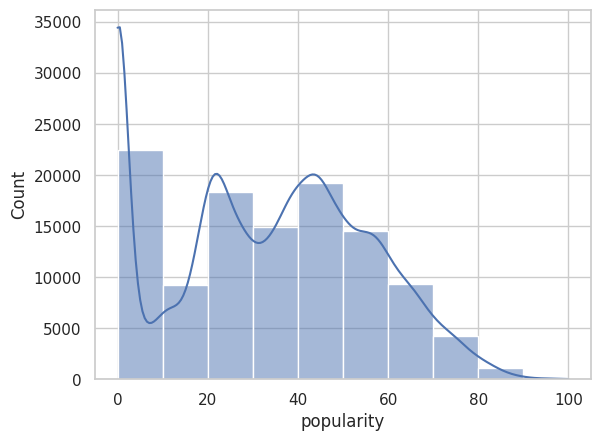

In [179]:
sns.histplot(data = df, x = "popularity", bins = 10, kde=True)

Se presencia una distribucion hacia la izquierda dandonos a entender que en la totalidad de las canciones la mayoria presenta un rango de popularidad [0-50] mientras que hay un numero reducido de canciones con un umbral de popularidad del [51-100], de ahi va en bajada.

<Axes: xlabel='popularity', ylabel='track_genre'>

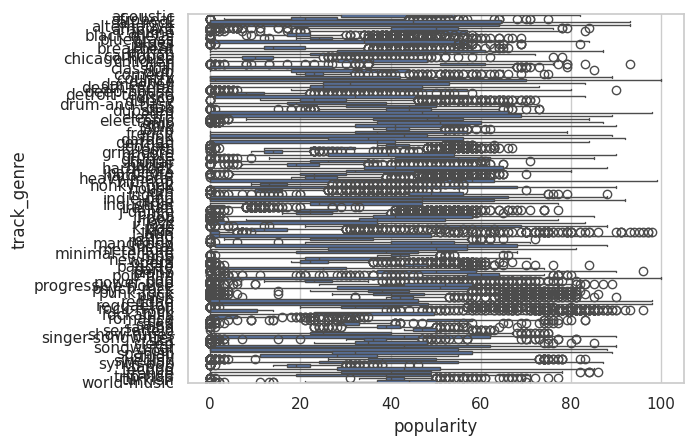

In [180]:
#que les parece chicos, clarito
sns.boxplot(data=df, x = "popularity", y = "track_genre")


eh claramente se observa la observacion observada bajo los supuestos observados

/tmp/ipykernel_6550/3615896823.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


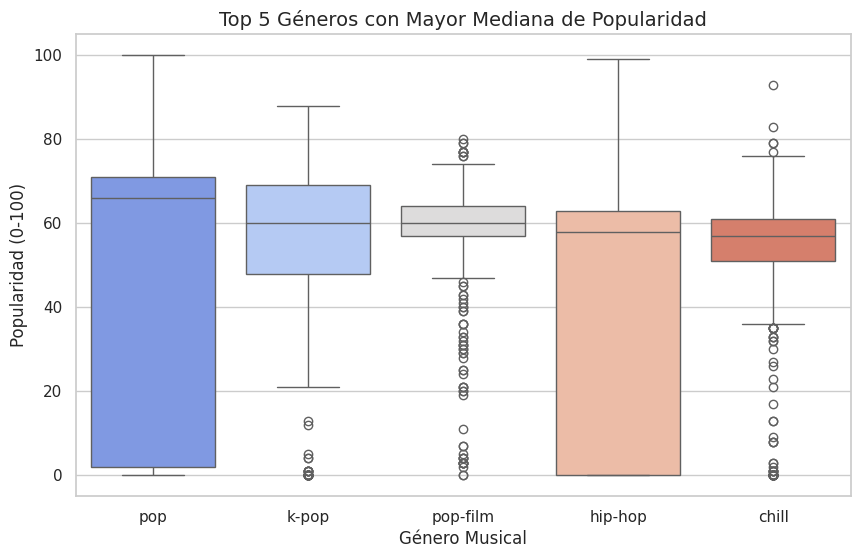

In [181]:

# 1. Identificar los 5 géneros con la mayor mediana de popularidad
top_5_generos = df.groupby('track_genre')['popularity'].median().nlargest(5).index

# 2. Filtrar el dataset para conservar solo las filas de esos 5 géneros
df_top5 = df[df['track_genre'].isin(top_5_generos)]

# 3. Generar el gráfico
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top5,
    x='track_genre',
    y='popularity',
    order=top_5_generos, # Ordena visualmente de mayor a menor
    palette='coolwarm'
)

# 4. Ajustes estéticos para la presentación
plt.title('Top 5 Géneros con Mayor Mediana de Popularidad', fontsize=14)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Popularidad (0-100)', fontsize=12)
plt.show()

El genero pop es el que se encuentra en la mayoria de canciones con una mediana arriba del 60 de popularidad dando un maximo de 100 a la vez que cuenta con un minimo de 0(aprox), generos como pop-fil y chill presentan una gran cantidad de outliers dandonos a interpretar hits unicos dentro del repertorio.

#ANALISIS ASI BN IMPROVISADO CHIQUES

La compañia de spotify busca predecir la popularidad de canciones y poder desarrollar un algoritmo de inteligencia musical, por lo tanto hace entrega del dataset cargado(puro chamuyo chiques) dentro del dataframe se busca priorizar la variable objetivo "popularidad" y comparar la correlacion de esta con otras variables.\
Para proteger la privacidad de los datos se ocupa la funcion SHA-256 para encriptarlos y mantenerlos anonimos, esto ayuda a mantener la integridad de los datos de llegada para verificar que no esten corrompidos, asegurando el cumplimiento da ley de proteccion de datos 21.719.\
El dataset presenta cierta de cantidad de datos con poca relevancia estadistica o duplicados, como se comprueba al buscar filas que tengan la columna "track_id" y "track_genre" con los mismos datos, se opta eliminarlos para mitigar sesgo innecesario, no obstante, se mantienen filas que tienen los mismos datos a excepcion del genero, debido a la importancia del ultimo en un modelo que busca predecir la popularidad, a consciencia del sesgo que llegara a producir dentro del algoritmo(ya que no hemos encontrado forma optima de tratarlo gemini activate).\
Se opta de la eliminacion de variables como 'track_id', 'track_name', 'album_name', 'energy' y 'Unnamed: 0', por la alta correlacion con la variable objetivo, ya que si fuera entrenado con esto se produciria sobreajuste(era ese verda, si, a ya).\
La variable 'artist' se busca mantener a pesar de su alta correlacion con el objetivo debido a la importancia del artista al momento de predecir popularidad, por lo tanto se transforma los datos manteniendo a los artistas que cuentan con mas de 15 canciones, asegurando que el algoritmo aprenda los patrones de popularidad, los demas que cuenten con una menor cantidad seran etiquetados como "Otros", esto a consciencia de bandas indie o artistas de un solo exito donde el algoritmo no aprendera y su prescencia solo aportara ruido.
